In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from skimage.feature import graycomatrix, graycoprops

In [13]:
SIZE = 128

In [14]:
train_df = pd.read_csv(f'features/{SIZE}/train_features.csv')
valid_df = pd.read_csv(f'features/{SIZE}/valid_features.csv')

In [15]:
X_train = train_df.drop(columns=["filename", "label"])
y_train = train_df["label"]

X_test = valid_df.drop(columns=["filename", "label"])
y_test = valid_df["label"]

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
joblib.dump(scaler, f"features/{SIZE}/grape_scaler.pkl")

['features/128/grape_scaler.pkl']

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [19]:
joblib.dump(knn, f"models/knn/{SIZE}/grape_knn.pkl")

['models/knn/128/grape_knn.pkl']

In [20]:
# Prediksi data train
y_train_pred = knn.predict(X_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.9466939331970007
Testing Accuracy  : 0.9161643835616439

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.88      0.87      0.87       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.96      0.99      0.97       430
                      grape leaf Healthy       0.97      0.98      0.98       435
                    grape leaf black rot       0.86      0.84      0.85       480

                                accuracy                           0.92      1825
                               macro avg       0.92      0.92      0.92      1825
                            weighted avg       0.92      0.92      0.92      1825



In [ ]:
# Cross Validation KNN
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn, 
    X_train_scaled, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("KNN Cross Validation Scores:")
print(f"Scores per fold: {knn_cv_scores}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {knn_cv_scores.std():.4f}")

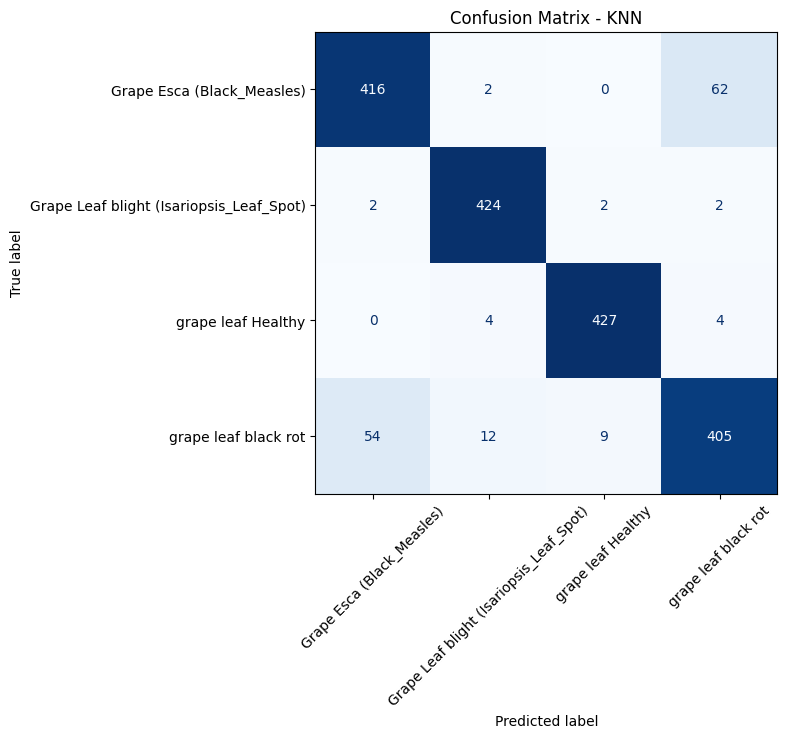

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

In [22]:
le = LabelEncoder()

y_train_ann = le.fit_transform(train_df["label"])
y_test_ann = le.transform(valid_df["label"])

print(le.classes_)

print("Contoh y encoded:", y_train_ann[:5])

['Grape Esca (Black_Measles)' 'Grape Leaf blight (Isariopsis_Leaf_Spot)'
 'grape leaf Healthy' 'grape leaf black rot']
Contoh y encoded: [0 0 0 0 0]


In [23]:
joblib.dump(le, f"models/ann/{SIZE}/grape_label_encoder.pkl")

['models/ann/128/grape_label_encoder.pkl']

In [24]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

ann.fit(X_train_scaled, y_train_ann)

Iteration 1, loss = 0.59106379
Validation score: 0.876022
Iteration 2, loss = 0.27779308
Validation score: 0.912807
Iteration 3, loss = 0.20625141
Validation score: 0.923706
Iteration 4, loss = 0.16710628
Validation score: 0.938692
Iteration 5, loss = 0.14449848
Validation score: 0.941417
Iteration 6, loss = 0.14836015
Validation score: 0.940054
Iteration 7, loss = 0.11897306
Validation score: 0.949591
Iteration 8, loss = 0.10665534
Validation score: 0.952316
Iteration 9, loss = 0.09580926
Validation score: 0.935967
Iteration 10, loss = 0.18954945
Validation score: 0.941417
Iteration 11, loss = 0.10373267
Validation score: 0.955041
Iteration 12, loss = 0.10248566
Validation score: 0.949591
Iteration 13, loss = 0.08396346
Validation score: 0.959128
Iteration 14, loss = 0.07506903
Validation score: 0.959128
Iteration 15, loss = 0.06955764
Validation score: 0.956403
Iteration 16, loss = 0.06415719
Validation score: 0.960490
Iteration 17, loss = 0.06016107
Validation score: 0.957766
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=300,
              n_iter_no_change=20, random_state=42, verbose=True)

In [25]:
joblib.dump(ann, f"models/ann/{SIZE}/grape_mlp.pkl")

['models/ann/128/grape_mlp.pkl']

In [26]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

train_acc_ann = accuracy_score(
    y_train_ann,
    y_train_pred_ann
)

test_acc_ann = accuracy_score(
    y_test_ann,
    y_test_pred_ann
)

print("Training Accuracy:", train_acc_ann)
print("Testing Accuracy :", test_acc_ann)

print("\nClassification Report:\n")
print(classification_report(y_test_ann, y_test_pred_ann, target_names=le.classes_))

Training Accuracy: 0.9959100204498977
Testing Accuracy : 0.9654794520547946

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.96      0.94      0.95       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.99      0.98      0.99       430
                      grape leaf Healthy       0.99      0.99      0.99       435
                    grape leaf black rot       0.93      0.95      0.94       480

                                accuracy                           0.97      1825
                               macro avg       0.97      0.97      0.97      1825
                            weighted avg       0.97      0.97      0.97      1825



In [ ]:
# Cross Validation MLP
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_cv_scores = cross_val_score(
    ann, 
    X_train_scaled, 
    y_train_ann, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("MLP Cross Validation Scores:")
print(f"Scores per fold: {mlp_cv_scores}")
print(f"Mean CV Accuracy: {mlp_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {mlp_cv_scores.std():.4f}")

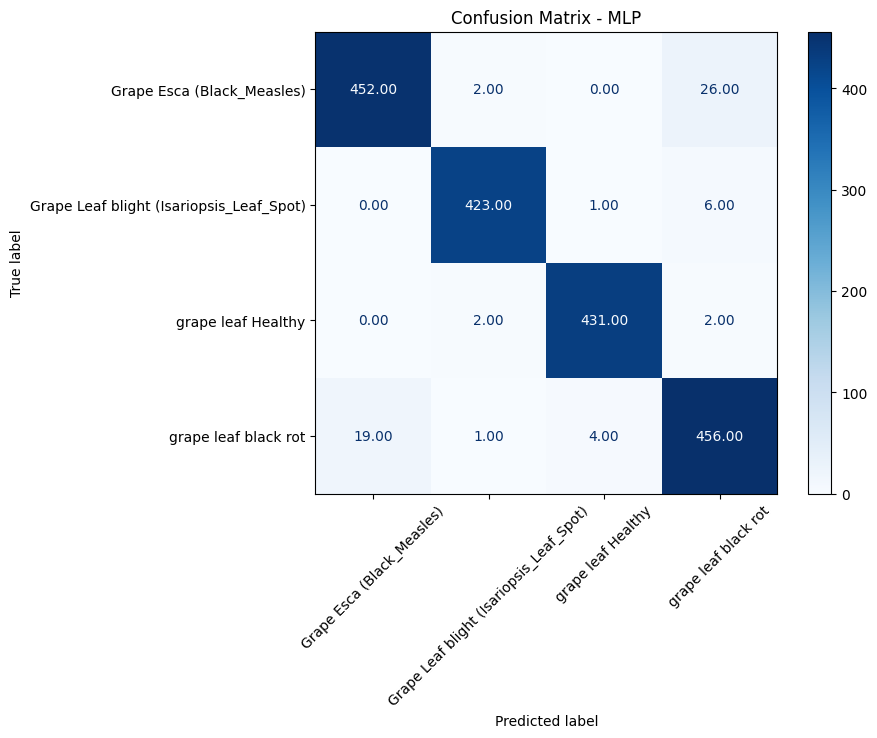

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(
    y_test_ann,
    y_test_pred_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - MLP")
plt.show()